In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
X = np.array([
    [-1, -1],
    [-1, 1],
    [1, -1],
    [1, 1]
])

z = np.array([
    [-1],
    [1],
    [1],
    [-1]
])

In [21]:
def sigmoid(y):
    return 2.0/(1+np.exp(-y)) - 1.0

def sigmoid_derivative(y):
    z = sigmoid(y)
    return 0.5 * (1-z) * (1+z)

In [7]:
def prediction(X, W1, W2, b1, b2):
    layer0 = X
    y1 = np.dot(X, W1) + b1
    layer1 = sigmoid(y1)
    y2 = np.dot(layer1, W2) + b2
    layer2 = sigmoid(y2)
    return layer0, layer1, layer2

In [99]:
y1 = np.dot(X, W1) + b1 
layer1 = sigmoid(y1)
y2 = np.dot(layer1, W2) + b2 

print(y1)
print(layer1)

[[0.  2. ]
 [0.5 1.5]
 [0.5 1.5]
 [1.  1. ]]
[[0.5 1. ]
 [1.  1. ]
 [1.  1. ]
 [1.  1. ]]


In [91]:
layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
decision = layer2 >= 0.5
error = np.sum(np.abs(decision-z))
print(error)
print(layer2)

2
[[0.51672512]
 [0.9999481 ]
 [0.9999481 ]
 [0.51672512]]


### Loss = MSE

In [8]:
def fit(X, W1, W2, b1, b2, z, it_max=60000):
    lossArray = []
    learning_rate = 0.5
    for epoch in range(it_max):
        # prediction
        layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
        z_2_hat = layer2
        
        # check break condition 
        decision = z_2_hat.copy()
        decision[decision>=0] = 1
        decision[decision<0] = -1
        error = np.sum(np.abs(decision-z))
        loss = np.sum(np.abs(z_2_hat-z))
        lossArray.append(loss)
        print(epoch, int(error), loss, z_2_hat.T)
        #if error == 0:   break
        
        # Backpropagation
        layer2_error = layer2 - z
        layer2_delta = layer2_error * sigmoid_derivative(layer2)
        dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
        db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)
        
        layer1_error = np.dot(layer2_delta, W2.T)
        layer1_delta = layer1_error * sigmoid_derivative(layer1)
        dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
        db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)
        
        # Update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1   

    return W1, W2, b1, b2, np.array(lossArray), decision

In [11]:
it_max = 1000
W1_out, W2_out, b1_out, b2_out, lossArray, decision = fit(X, W1, W2, b1, b2, z, it_max)

0 2 2.015445427544606 [[-0.99240279  0.99582795  0.99582795  0.99950413]]
1 2 2.023449889051248 [[-0.99190074  0.99199078  0.99199078  0.99933218]]
2 2 2.039397770085375 [[-0.99145001  0.98412682  0.98412682  0.99910141]]
3 2 2.0719705930157293 [[-0.99105337  0.96788465  0.96788465  0.99879326]]
4 2 2.137688676586839 [[-0.99070514  0.934996    0.934996    0.99838581]]
5 2 2.2620183848879187 [[-0.99038439  0.87272722  0.87272722  0.99785723]]
6 2 2.4663403960172507 [[-0.99004377  0.77040536  0.77040536  0.99719489]]
7 2 2.7315808951675766 [[-0.98959991  0.63761456  0.63761456  0.99640993]]
8 2 2.9845825189914508 [[-0.98895215  0.51100226  0.51100226  0.99553919]]
9 2 3.1640984282774633 [[-0.98804279  0.42123572  0.42123572  0.99461266]]
10 2 3.2691275237155173 [[-0.98688487  0.36880573  0.36880573  0.99362385]]
11 2 3.326165131272101 [[-0.98551851  0.3404295   0.3404295   0.99254265]]
12 2 3.357391032515844 [[-0.98397243  0.3249857   0.3249857   0.99133486]]
13 2 3.3755857852615287 [[-0

In [13]:
print(W1_out, b1_out, W2_out, b2_out, sep='\n')

[[ 2.1708138 -2.0311844]
 [ 2.1708138 -2.0311844]]
[0.9972386  0.88409585]
[[8.080207]
 [8.143   ]]
[-3.7199533]


In [14]:
import matplotlib.pyplot as plt

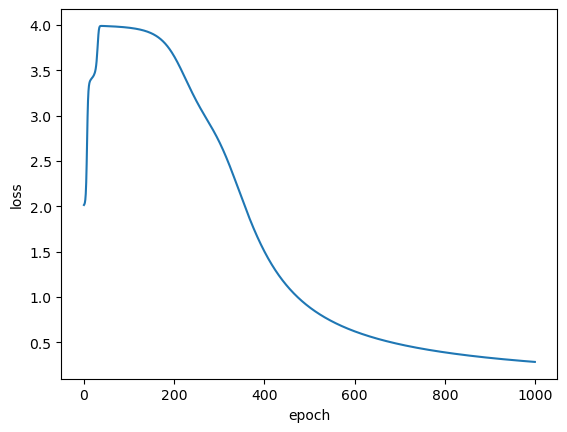

In [16]:
plt.plot(lossArray)
plt.xlabel("epoch")
plt.ylabel("loss")
#plt.ylim(1,2)
plt.show()

In [61]:
class myModel:
    def __init__(self, X, z, learning_rate = 0.1, it_max = 1000):
        inputs, hiddens, outputs = 2, 2, 1
        self.W1 = np.random.randn(inputs, hiddens) 
        self.W2 = np.random.randn(hiddens, outputs) 
        self.b1 = np.zeros(hiddens)
        self.b2 = np.zeros(outputs)
        self.learning_rate = learning_rate
        self.it_max = it_max
        self.X = X
        self.z = z

    def sigmoid(self, y):
        return 2.0/(1+np.exp(-y)) - 1.0
    
    def sigmoid_derivative(self, y):
        z = self.sigmoid(y)
        return 0.5 * (1-z) * (1+z)

    def prediction(self, X):
        W1, W2, b1, b2 = self.W1, self.W2, self.b1, self.b2
        layer0 = X
        y1 = np.dot(X, W1) + b1
        layer1 = self.sigmoid(y1)
        y2 = np.dot(layer1, W2) + b2
        layer2 = self.sigmoid(y2)
        return layer0, layer1, layer2

    def plotLosses(self, xrange):
        new_xrange = np.min((xrange, len(self.lossArray)))
        plt.plot(self.lossArray[0:new_xrange])
        plt.xlabel("epoch")
        plt.ylabel("loss")
        #plt.ylim(1,2)
        plt.show()

    def fit(self, X, z):
        self.lossArray = []
        learning_rate = self.learning_rate
        for epoch in range(self.it_max):
            # prediction
            layer0, layer1, layer2 = self.prediction(X)
            z_2_hat = layer2
            
            # check break condition 
            self.decision = z_2_hat.copy()
            self.decision[self.decision>=0] = 1
            self.decision[self.decision<0] = -1
            error = np.sum(np.abs(self.decision-z))
            loss = np.sum(np.abs(z_2_hat-z))
            self.lossArray.append(loss)
            print(epoch, int(error), loss, z_2_hat.T)
            #if error == 0:   break
            
            # Backpropagation
            layer2_error = layer2 - z
            layer2_delta = layer2_error * self.sigmoid_derivative(layer2)
            dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
            db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)
            
            layer1_error = np.dot(layer2_delta, self.W2.T)
            layer1_delta = layer1_error * self.sigmoid_derivative(layer1)
            dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
            db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)
            
            # Update
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2
            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1   
    
        #return W1, W2, b1, b2, np.array(lossArray), decision      


In [66]:
model = myModel(X, z, learning_rate = 0.5, it_max = 5000)

In [67]:
print(model.W1, model.W2, model.b1, model.b2, model.learning_rate, model.it_max, sep='\n')

[[ 0.45208705 -0.65515072]
 [ 0.11401625 -1.77926949]]
[[0.37181742]
 [1.08015602]]
[0. 0.]
[0.]
0.5
5000


In [68]:
model.fit(X, z)

0 4 4.0 [[ 0.38146514 -0.29706828  0.29706828 -0.38146514]]
1 4 3.9983565566437225 [[ 0.35721634 -0.27453741  0.27874019 -0.354657  ]]
2 4 3.9969995627663026 [[ 0.33437237 -0.25454508  0.26210325 -0.32981464]]
3 4 3.9958818122213686 [[ 0.31287312 -0.23680005  0.24695349 -0.30683787]]
4 4 3.994959996104158 [[ 0.29265726 -0.22102904  0.2331172  -0.2856091 ]]
5 4 3.994196713745303 [[ 0.27366363 -0.20698321  0.2204467  -0.26600342]]
6 4 3.9935608570641574 [[ 0.25583203 -0.19444062  0.20881615 -0.24789564]]
7 4 3.993027155225992 [[ 0.23910371 -0.18320607  0.19811788 -0.23116474]]
8 4 3.9925753666347266 [[ 0.22342153 -0.17310954  0.18825916 -0.21569654]]
9 4 3.9921893926410577 [[ 0.20873017 -0.16400395  0.17915965 -0.20138508]]
10 4 3.9918564509270595 [[ 0.19497616 -0.15576258  0.17074918 -0.18813312]]
11 4 3.991566365751406 [[ 0.18210799 -0.14827658  0.16296609 -0.1758521 ]]
12 4 3.991310988111917 [[ 0.17007606 -0.14145254  0.15575583 -0.16446178]]
13 4 3.9910837371763797 [[ 0.15883279 -0.1

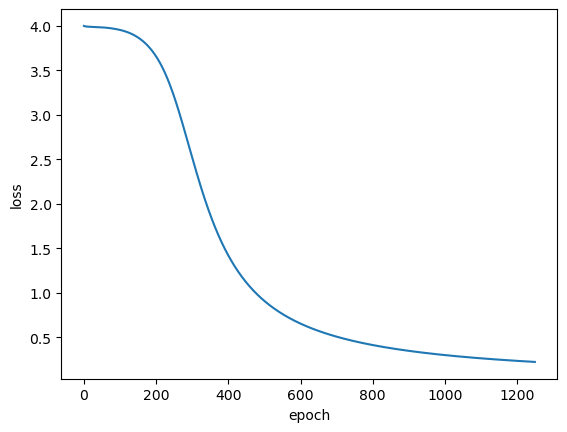

In [72]:
model.plotLosses(int(len(model.lossArray)/4))